In [ ]:
# --------------------------
# 1. Import Required Libraries
# --------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc)

First 5 rows of the dataset:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Streami

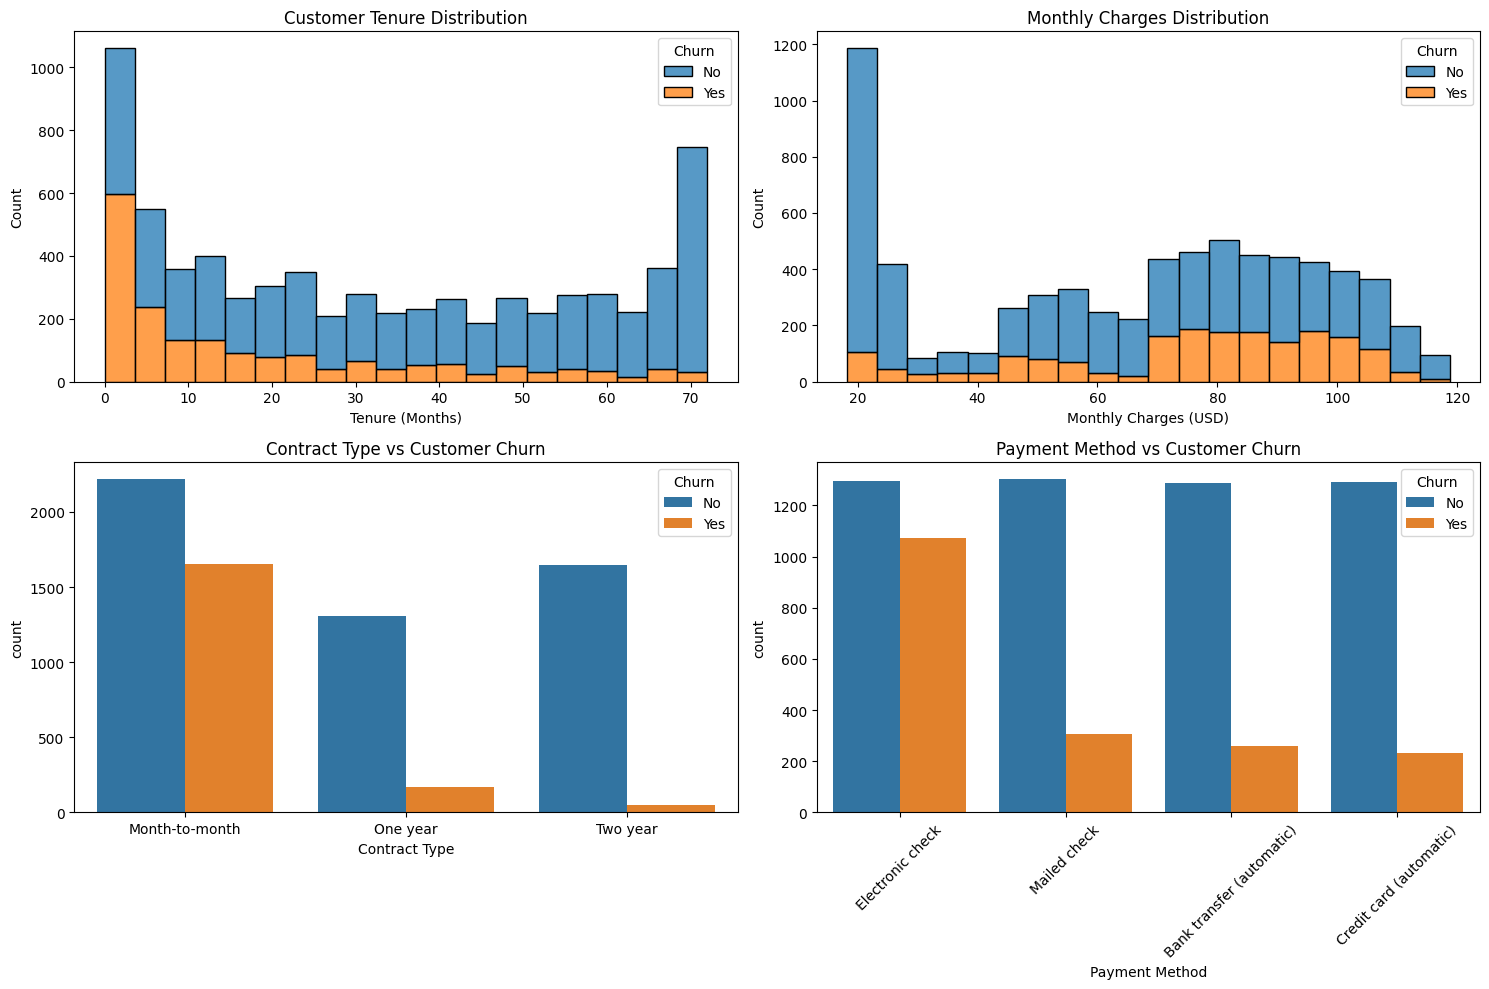

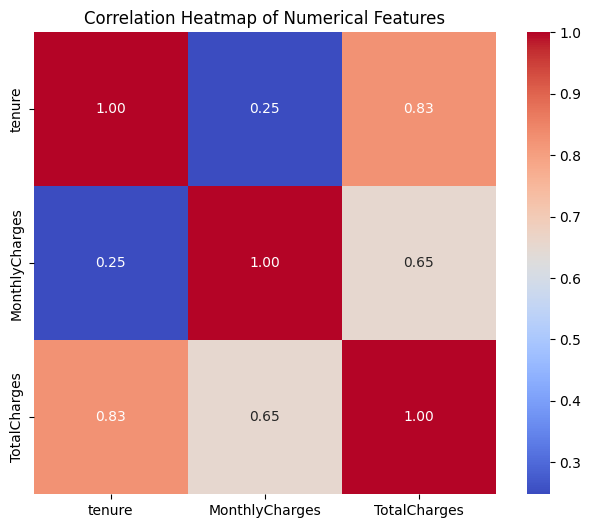

In [10]:
# --------------------------
# 2. Data Loading and Exploration (10 pts)
# --------------------------
# Load dataset (ensure file is in the same directory)
df = pd.read_csv('./Telco-Customer-Churn.csv')

# Display first 5 rows
print("First 5 rows of the dataset:")
print(df.head())

# Basic dataset information
print("\nDataset information:")
print(df.info())

# Statistical summary of numerical features
print("\nStatistical summary of numerical features:")
print(df.describe())

# Target variable distribution
print("\nTarget variable (Churn) distribution:")
print(df['Churn'].value_counts())
print(f"Churn rate: {df['Churn'].value_counts(normalize=True)['Yes']:.2%}")

# Visualize key feature distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Tenure distribution
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=20, ax=axes[0,0])
axes[0,0].set_title('Customer Tenure Distribution')
axes[0,0].set_xlabel('Tenure (Months)')

# Monthly Charges distribution
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack', bins=20, ax=axes[0,1])
axes[0,1].set_title('Monthly Charges Distribution')
axes[0,1].set_xlabel('Monthly Charges (USD)')

# Contract type vs Churn
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[1,0])
axes[1,0].set_title('Contract Type vs Customer Churn')
axes[1,0].set_xlabel('Contract Type')

# Payment method vs Churn
sns.countplot(data=df, x='PaymentMethod', hue='Churn', ax=axes[1,1])
axes[1,1].set_title('Payment Method vs Customer Churn')
axes[1,1].set_xlabel('Payment Method')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Correlation heatmap for numerical features only
# Convert TotalCharges to numeric first
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(8, 6))
corr_matrix = df[numeric_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [11]:
# --------------------------
# 3. Data Preprocessing (20 pts)
# --------------------------
# Step 1: Convert numeric-like column (TotalCharges) to numeric format
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Step 2: Split features and target variable
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

# Step 3: Split into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 4: One-Hot Encoding for categorical variables
# Fixed typos from original PDF: Multiplelines → MultipleLines, onlinesecurity → OnlineSecurity, Techsupport → TechSupport
cat_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 
    'PaperlessBilling', 'PaymentMethod'
]

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(X_train[cat_cols])

# Transform training and test sets
train_enc = encoder.transform(X_train[cat_cols])
test_enc = encoder.transform(X_test[cat_cols])

# Convert to DataFrame and merge back
train_enc_df = pd.DataFrame(
    train_enc, 
    columns=encoder.get_feature_names_out(cat_cols), 
    index=X_train.index
)
test_enc_df = pd.DataFrame(
    test_enc, 
    columns=encoder.get_feature_names_out(cat_cols), 
    index=X_test.index
)

X_train = X_train.drop(columns=cat_cols).join(train_enc_df)
X_test = X_test.drop(columns=cat_cols).join(test_enc_df)

# Step 5: Check and handle missing values
print('Training dataset missing values:')
print(X_train.isnull().sum())
print('\nTesting dataset missing values:')
print(X_test.isnull().sum())

# Impute missing values in TotalCharges (mean strategy)
imputer = SimpleImputer(strategy='mean')
imputer.fit(X_train[['TotalCharges']])

# Fixed syntax error from original PDF
X_train['TotalCharges'] = imputer.transform(X_train[['TotalCharges']]).ravel()
X_test['TotalCharges'] = imputer.transform(X_test[['TotalCharges']]).ravel()

# Step 6: Feature scaling (StandardScaler)
# Fixed typo from original PDF: Standardscaler → StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nProcessed training set shape: {X_train_scaled.shape}")
print(f"Processed test set shape: {X_test_scaled.shape}")

Training dataset missing values:
SeniorCitizen                               0
tenure                                      0
MonthlyCharges                              0
TotalCharges                               10
gender_Female                               0
gender_Male                                 0
Partner_No                                  0
Partner_Yes                                 0
Dependents_No                               0
Dependents_Yes                              0
PhoneService_No                             0
PhoneService_Yes                            0
MultipleLines_No                            0
MultipleLines_No phone service              0
MultipleLines_Yes                           0
InternetService_DSL                         0
InternetService_Fiber optic                 0
InternetService_No                          0
OnlineSecurity_No                           0
OnlineSecurity_No internet service          0
OnlineSecurity_Yes                          0
O

In [12]:
# --------------------------
# 4. Model Building (20 pts)
# --------------------------
# Build KNN model (default parameters)
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
y_pred_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]

# Build Decision Tree model (default parameters)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
y_pred_proba_dt = dt.predict_proba(X_test_scaled)[:, 1]

print("Models trained successfully!")

Models trained successfully!


KNN Model Evaluation
KNN Accuracy: 0.7608232789212207

KNN Classification Report:
               precision    recall  f1-score   support

          No       0.83      0.85      0.84      1036
         Yes       0.55      0.51      0.53       373

    accuracy                           0.76      1409
   macro avg       0.69      0.68      0.69      1409
weighted avg       0.76      0.76      0.76      1409


Decision Tree Model Evaluation
Decision Tree Accuracy: 0.7154009936124911

Decision Tree Classification Report:
               precision    recall  f1-score   support

          No       0.81      0.80      0.80      1036
         Yes       0.46      0.49      0.47       373

    accuracy                           0.72      1409
   macro avg       0.64      0.64      0.64      1409
weighted avg       0.72      0.72      0.72      1409



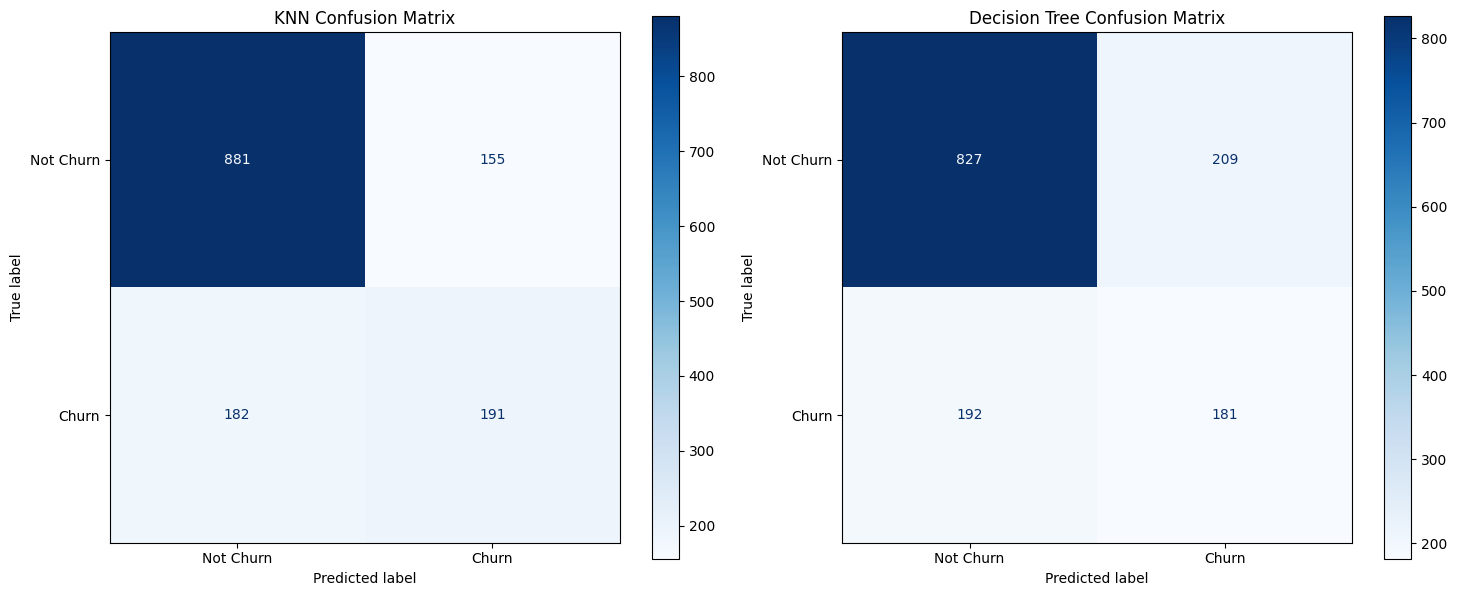

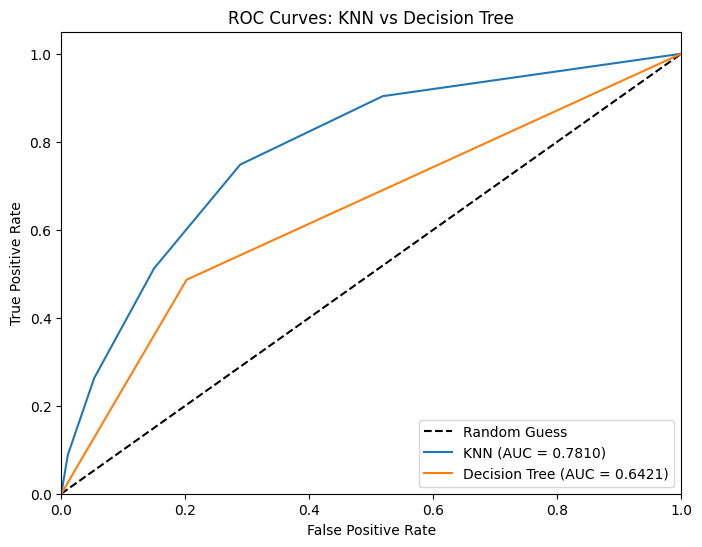

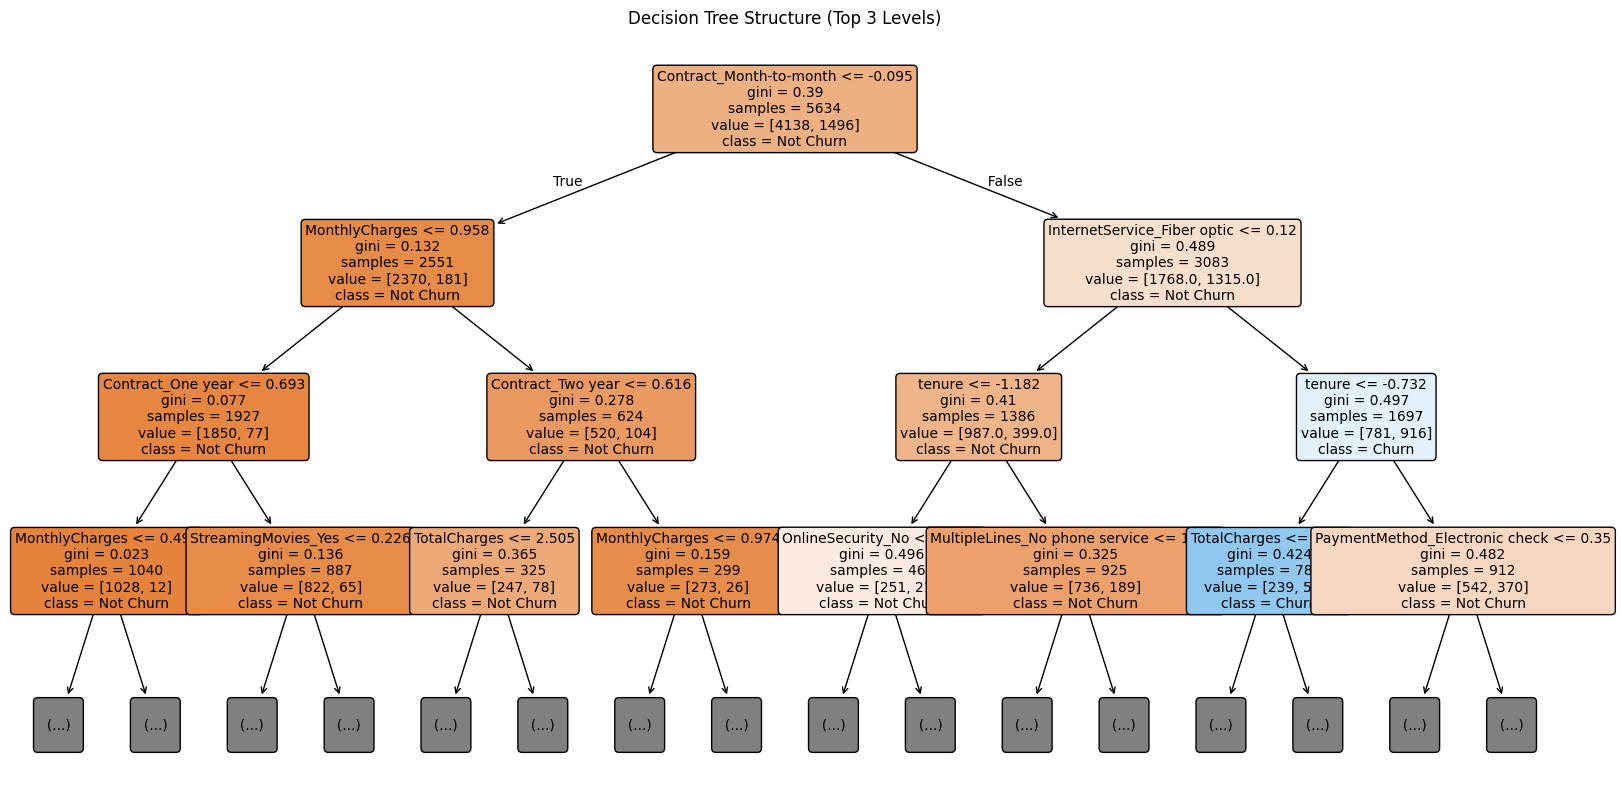

: 

In [ ]:
# --------------------------
# 5. Model Evaluation (20 pts)
# --------------------------
# 5.1 Accuracy and Classification Report
print("="*50)
print("KNN Model Evaluation")
print("="*50)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nKNN Classification Report:\n", classification_report(y_test, y_pred_knn))

print("\n" + "="*50)
print("Decision Tree Model Evaluation")
print("="*50)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nDecision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))

# 5.2 Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# KNN Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=['No', 'Yes'])
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Not Churn', 'Churn'])
disp_knn.plot(cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title('KNN Confusion Matrix')

# Decision Tree Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=['No', 'Yes'])
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Not Churn', 'Churn'])
disp_dt.plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title('Decision Tree Confusion Matrix')

plt.tight_layout()
plt.show()

# 5.3 ROC Curves
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# KNN ROC
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_proba_knn, pos_label='Yes')
roc_auc_knn = auc(fpr_knn, tpr_knn)
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_knn:.4f})')

# Decision Tree ROC
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt, pos_label='Yes')
roc_auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.4f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: KNN vs Decision Tree')
plt.legend(loc="lower right")
plt.show()

# 5.4 Decision Tree Structure (first 3 layers)
plt.figure(figsize=(20, 10))
plot_tree(
    dt, 
    max_depth=3, 
    feature_names=X_train.columns,
    class_names=['Not Churn', 'Churn'],
    filled=True, 
    rounded=True, 
    fontsize=10
)
plt.title('Decision Tree Structure (Top 3 Levels)')
plt.savefig('./decision_tree.png', dpi=1200)
plt.show()

In [14]:
# --------------------------
# 6. Hyperparameter Tuning (15 pts)
# --------------------------
# KNN Hyperparameter Tuning
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
knn_grid.fit(X_train_scaled, y_train)

print("Best Hyperparameters for KNN:")
print(knn_grid.best_params_)
print(f"Best KNN Cross-Validation Accuracy: {knn_grid.best_score_:.4f}")

# Decision Tree Hyperparameter Tuning
dt_param_grid = {
    'max_depth': [3, 5, 7, 9, 11, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
dt_grid.fit(X_train_scaled, y_train)

print("\nBest Hyperparameters for Decision Tree:")
print(dt_grid.best_params_)
print(f"Best Decision Tree Cross-Validation Accuracy: {dt_grid.best_score_:.4f}")

# Get best models
best_knn = knn_grid.best_estimator_
best_dt = dt_grid.best_estimator_

# Evaluate best models on test set
y_pred_best_knn = best_knn.predict(X_test_scaled)
y_pred_best_dt = best_dt.predict(X_test_scaled)

print(f"\nTuned KNN Test Accuracy: {accuracy_score(y_test, y_pred_best_knn):.4f}")
print(f"Tuned Decision Tree Test Accuracy: {accuracy_score(y_test, y_pred_best_dt):.4f}")

C:\Users\hetia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.74121412 0.72967765 0.75363947 0.74299016 0.76535199 0.74760308
 0.76570754 0.75133105 0.77227443 0.7559457  0.77280871 0.7573665
 0.77422731 0.76055972        nan 0.73145164        nan 0.73926235
        nan 0.74653736        nan 0.75150709        nan 0.75487887
        nan 0.75647745        nan 0.76020542]
  warnings.warn(


Best Hyperparameters for KNN:
{'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'uniform'}
Best KNN Cross-Validation Accuracy: 0.7742

Best Hyperparameters for Decision Tree:
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best Decision Tree Cross-Validation Accuracy: 0.7868

Tuned KNN Test Accuracy: 0.7885
Tuned Decision Tree Test Accuracy: 0.7999


In [15]:
# --------------------------
# 7. Cross Validation (10 pts)
# --------------------------
cv_folds = 5

# KNN 5-Fold Cross Validation
knn_cv_scores = cross_val_score(best_knn, X_train_scaled, y_train, cv=cv_folds, scoring='accuracy')
print(f"KNN {cv_folds}-Fold Cross Validation Scores:")
for i, score in enumerate(knn_cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")
print(f"KNN Average CV Accuracy: {knn_cv_scores.mean():.4f} (Standard Deviation: {knn_cv_scores.std():.4f})")

# Decision Tree 5-Fold Cross Validation
dt_cv_scores = cross_val_score(best_dt, X_train_scaled, y_train, cv=cv_folds, scoring='accuracy')
print(f"\nDecision Tree {cv_folds}-Fold Cross Validation Scores:")
for i, score in enumerate(dt_cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")
print(f"Decision Tree Average CV Accuracy: {dt_cv_scores.mean():.4f} (Standard Deviation: {dt_cv_scores.std():.4f})")

KNN 5-Fold Cross Validation Scores:
Fold 1: 0.7799
Fold 2: 0.7737
Fold 3: 0.7817
Fold 4: 0.7649
Fold 5: 0.7709
KNN Average CV Accuracy: 0.7742 (Standard Deviation: 0.0061)

Decision Tree 5-Fold Cross Validation Scores:
Fold 1: 0.7968
Fold 2: 0.7986
Fold 3: 0.7684
Fold 4: 0.7808
Fold 5: 0.7895
Decision Tree Average CV Accuracy: 0.7868 (Standard Deviation: 0.0111)


Model Performance Comparison Table:
                     Model  Test Accuracy  AUC Score  \
0            KNN (Default)         0.7608     0.7810   
1  Decision Tree (Default)         0.7154     0.6421   
2              KNN (Tuned)         0.7885     0.8338   
3    Decision Tree (Tuned)         0.7999     0.8400   

   5-Fold CV Average Accuracy  
0                      0.7536  
1                      0.7307  
2                      0.7742  
3                      0.7868  


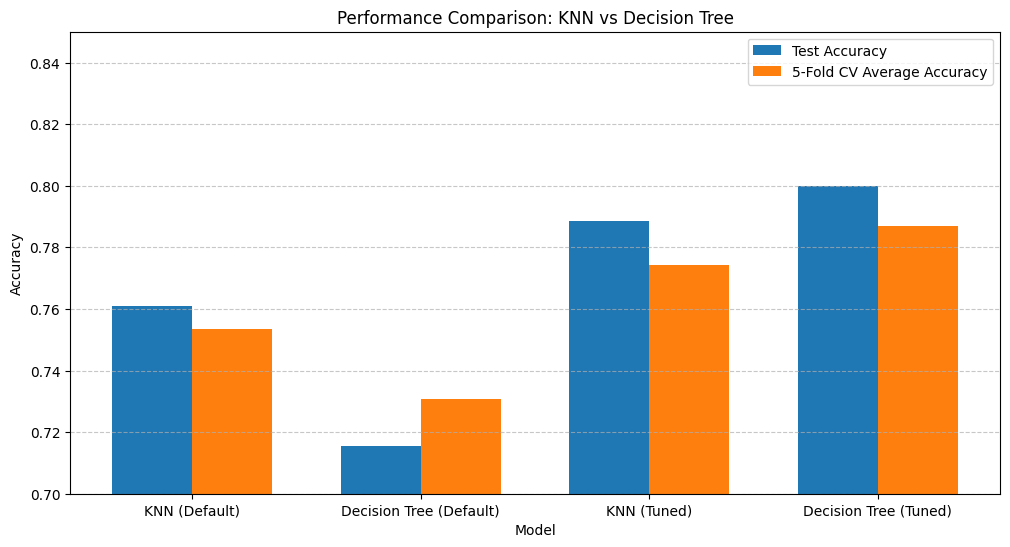

In [16]:
# --------------------------
# 8. Performance Comparison (5 pts)
# --------------------------
# Create performance comparison table
comparison_data = {
    'Model': ['KNN (Default)', 'Decision Tree (Default)', 'KNN (Tuned)', 'Decision Tree (Tuned)'],
    'Test Accuracy': [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_best_knn),
        accuracy_score(y_test, y_pred_best_dt)
    ],
    'AUC Score': [roc_auc_knn, roc_auc_dt,
                  auc(*roc_curve(y_test, best_knn.predict_proba(X_test_scaled)[:,1], pos_label='Yes')[:2]),
                  auc(*roc_curve(y_test, best_dt.predict_proba(X_test_scaled)[:,1], pos_label='Yes')[:2])],
    '5-Fold CV Average Accuracy': [
        cross_val_score(knn, X_train_scaled, y_train, cv=5).mean(),
        cross_val_score(dt, X_train_scaled, y_train, cv=5).mean(),
        knn_cv_scores.mean(),
        dt_cv_scores.mean()
    ]
}

comparison_df = pd.DataFrame(comparison_data).round(4)
print("Model Performance Comparison Table:")
print(comparison_df)

# Visualize performance comparison
plt.figure(figsize=(12, 6))
x = np.arange(len(comparison_df['Model']))
width = 0.35

plt.bar(x - width/2, comparison_df['Test Accuracy'], width, label='Test Accuracy')
plt.bar(x + width/2, comparison_df['5-Fold CV Average Accuracy'], width, label='5-Fold CV Average Accuracy')

plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Performance Comparison: KNN vs Decision Tree')
plt.xticks(x, comparison_df['Model'])
plt.ylim(0.7, 0.85)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()